# Selección del Mejor Modelo - Diabetes

### By:
Maria Camila Aristizábal Aguirre

### Date:
2026-08-19

## 📚 Import  libraries

In [1]:
from pathlib import Path

import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

## 💾 Load data

In [2]:
MODEL_INPUT_DIR = Path("../../data/05_model_input")
train = pd.read_parquet(MODEL_INPUT_DIR / "train.parquet")
test = pd.read_parquet(MODEL_INPUT_DIR / "test.parquet")

COLUMNAS_FEATURES = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]
TARGET = "Outcome"

X_train, y_train = train[COLUMNAS_FEATURES], train[TARGET].astype(bool)
X_test, y_test = test[COLUMNAS_FEATURES], test[TARGET].astype(bool)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (629, 8) | Test: (158, 8)


## 👷 Data preparation

##  Decisiones

- Se reutiliza el split de `data/05_model_input/` ya imputado (con log-transform
  de la Tarea 4 aplicado a Insulin/DiabetesPedigreeFunction) — no se genera uno
  nuevo.
- Se comparan 5 modelos de familias distintas: Regresión Logística, Árbol de
  Decisión, Random Forest, KNN y SVM.
- Se aplica `StandardScaler` de forma uniforme en el pipeline de los 5 modelos:
  no afecta a los árboles (invariantes a escalado monótono) y es necesario para
  Regresión Logística, KNN y SVM.
- Comparación inicial con `KFold(5)`; se seleccionan **todos los modelos con F1
  por encima del promedio** de los 5 (no un top-2 fijo), siguiendo el criterio
  literal del issue #17. Resultado: 3 modelos (Random Forest, KNN, Regresión
  Logística) se afinan con `GridSearchCV(cv=5)`, incluyendo `class_weight`
  como hiperparámetro (dataset con desbalance moderado 65/35).
- Se aplica una prueba estadística pareada (Wilcoxon signed-rank sobre F1 por
  fold) entre los 3 modelos afinados, en vez de ANOVA: ANOVA de una vía no es
  apropiado para comparar el mismo conjunto de folds entre modelos relacionados
  (muestras pareadas, no independientes); Wilcoxon es la alternativa no
  paramétrica correcta para este caso.
- Se agregan Learning Curve y análisis de escalabilidad (tiempo de ajuste vs.
  tamaño de datos) para los 3 modelos afinados.
- Métrica principal de selección: **F1** (balancea precision y recall, a raíz de
  lo aprendido en la Tarea 5 sobre el trade-off entre ambas).

## Modelos candidatos (pipeline con escalado uniforme)

In [3]:
SEMILLA = 42

modelos_candidatos = {
    "Regresion Logistica": LogisticRegression(random_state=SEMILLA, max_iter=1000),
    "Arbol de Decision": DecisionTreeClassifier(random_state=SEMILLA),
    "Random Forest": RandomForestClassifier(random_state=SEMILLA),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(random_state=SEMILLA),
}

pipelines = {
    nombre: Pipeline(steps=[("scaler", StandardScaler()), ("model", modelo)])
    for nombre, modelo in modelos_candidatos.items()
}

## Comparación inicial con KFold(5)

In [4]:
K_FOLDS = 5
METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv = KFold(n_splits=K_FOLDS, shuffle=True, random_state=SEMILLA)

filas_comparacion = []
for nombre, pipe in pipelines.items():
    resultados = cross_validate(pipe, X_train, y_train, cv=cv, scoring=METRICAS)
    fila = {"modelo": nombre}
    for metrica in METRICAS:
        fila[f"{metrica}_media"] = resultados[f"test_{metrica}"].mean()
        fila[f"{metrica}_std"] = resultados[f"test_{metrica}"].std()
    filas_comparacion.append(fila)

tabla_comparacion = pd.DataFrame(filas_comparacion).set_index("modelo")
tabla_comparacion.sort_values("f1_media", ascending=False)

,accuracy_media,accuracy_std,precision_media,precision_std,recall_media,recall_std,f1_media,f1_std,roc_auc_media,roc_auc_std
modelo,,,,,,,,,,
Random Forest,0.771060,0.028157,0.697798,0.034860,0.614371,0.072868,0.652019,0.053050,0.835301,0.023337
KNN,0.748863,0.019841,0.653374,0.056205,0.605929,0.050466,0.627949,0.048396,0.796964,0.026379
Regresion Logistica,0.758311,0.047965,0.695808,0.068821,0.564657,0.059482,0.623034,0.062080,0.822158,0.041095
SVM,0.753511,0.040615,0.692077,0.050723,0.536246,0.082835,0.603099,0.071012,0.825091,0.034212
Arbol de Decision,0.683683,0.022497,0.544823,0.061574,0.600078,0.066289,0.570074,0.057789,0.663896,0.032696


## selección por promedio (3 modelos) + tuning + prueba estadística

In [ ]:
promedio_f1 = tabla_comparacion["f1_media"].mean()
modelos_seleccionados = tabla_comparacion[tabla_comparacion["f1_media"] > promedio_f1].sort_values(
    "f1_media", ascending=False
)
nombres_seleccionados = modelos_seleccionados.index.tolist()

print(f"Promedio de F1 entre los 5 modelos: {promedio_f1:.4f}")
print(f"Modelos por encima del promedio (se afinan): {nombres_seleccionados}")
modelos_seleccionados[["f1_media", "f1_std", "recall_media", "precision_media"]]

Promedio de F1 entre los 5 modelos: 0.6152
Modelos por encima del promedio (se afinan): ['Random Forest', 'KNN', 'Regresion Logistica']


,f1_media,f1_std,recall_media,precision_media
modelo,,,,
Random Forest,0.652019,0.053050,0.614371,0.697798
KNN,0.627949,0.048396,0.605929,0.653374
Regresion Logistica,0.623034,0.062080,0.564657,0.695808


## Afinamiento de hiperparámetros (GridSearchCV, cv=5)

In [6]:
param_grids = {
    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 15],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"],
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 9, 11, 15],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],
    },
    "Regresion Logistica": {
        "model__C": [0.01, 0.1, 1, 10, 100],
        "model__class_weight": [None, "balanced"],
        "model__solver": ["liblinear", "lbfgs"],
    },
}

In [7]:
modelos_afinados = {}
for nombre in nombres_seleccionados:
    grid = GridSearchCV(
        pipelines[nombre],
        param_grid=param_grids[nombre],
        cv=cv,
        scoring="f1",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    modelos_afinados[nombre] = grid
    print(f"--- {nombre} ---")
    print(f"Mejor F1 (CV): {grid.best_score_:.4f}")
    print(f"Mejores hiperparametros: {grid.best_params_}")
    print()

--- Random Forest ---
Mejor F1 (CV): 0.6996
Mejores hiperparametros: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}

--- KNN ---
Mejor F1 (CV): 0.6487
Mejores hiperparametros: {'model__n_neighbors': 9, 'model__p': 2, 'model__weights': 'distance'}

--- Regresion Logistica ---
Mejor F1 (CV): 0.6678
Mejores hiperparametros: {'model__C': 0.01, 'model__class_weight': 'balanced', 'model__solver': 'liblinear'}



## Prueba estadística entre los modelos afinados

In [8]:
from itertools import combinations

import numpy as np
from scipy import stats
from sklearn.model_selection import cross_val_score

scores_f1_por_modelo = {
    nombre: cross_val_score(grid.best_estimator_, X_train, y_train, cv=cv, scoring="f1")
    for nombre, grid in modelos_afinados.items()
}

for nombre, scores in scores_f1_por_modelo.items():
    print(f"{nombre}: F1 por fold = {np.round(scores, 3)}")

print("\nComparaciones pareadas (Wilcoxon signed-rank sobre F1 por fold):")
for modelo_a, modelo_b in combinations(scores_f1_por_modelo.keys(), 2):
    estadistico, p_valor = stats.wilcoxon(
        scores_f1_por_modelo[modelo_a], scores_f1_por_modelo[modelo_b]
    )
    print(f"{modelo_a} vs {modelo_b}: p-valor = {p_valor:.4f}")

Random Forest: F1 por fold = [0.681 0.622 0.768 0.698 0.729]
KNN: F1 por fold = [0.571 0.641 0.7   0.636 0.695]
Regresion Logistica: F1 por fold = [0.632 0.612 0.804 0.66  0.631]

Comparaciones pareadas (Wilcoxon signed-rank sobre F1 por fold):
Random Forest vs KNN: p-valor = 0.1250
Random Forest vs Regresion Logistica: p-valor = 0.1875
KNN vs Regresion Logistica: p-valor = 0.8125


## Ajuste del umbral de decisión

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import cross_val_predict

resultados_umbral_ajustado = []
umbrales_elegidos = {}

for nombre, grid in modelos_afinados.items():
    modelo = grid.best_estimator_
    proba_oof = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    precisiones, recalls, umbrales = precision_recall_curve(y_train, proba_oof)
    f1_por_umbral = 2 * (precisiones * recalls) / (precisiones + recalls + 1e-9)
    mejor_indice = f1_por_umbral[:-1].argmax()
    mejor_umbral = umbrales[mejor_indice]
    umbrales_elegidos[nombre] = mejor_umbral

    proba_test = modelo.predict_proba(X_test)[:, 1]
    y_pred_test = (proba_test >= mejor_umbral).astype(int)

    resultados_umbral_ajustado.append(
        {
            "modelo": f"{nombre} (umbral={mejor_umbral:.3f})",
            "accuracy": accuracy_score(y_test, y_pred_test),
            "precision": precision_score(y_test, y_pred_test),
            "recall": recall_score(y_test, y_pred_test),
            "f1": f1_score(y_test, y_pred_test),
        }
    )

tabla_umbral_ajustado = pd.DataFrame(resultados_umbral_ajustado).set_index("modelo")
tabla_umbral_ajustado.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1
modelo,,,,
Random Forest (umbral=0.436),0.740506,0.592593,0.857143,0.700730
Regresion Logistica (umbral=0.473),0.721519,0.576923,0.803571,0.671642
KNN (umbral=0.346),0.727848,0.594203,0.732143,0.656000


## Ensamble de los mejores modelos afinados

In [ ]:
from sklearn.ensemble import VotingClassifier

ensamble = VotingClassifier(
    estimators=[
        ("random_forest", modelos_afinados["Random Forest"].best_estimator_),
        (
            "regresion_logistica",
            modelos_afinados["Regresion Logistica"].best_estimator_,
        ),
    ],
    voting="soft",
)
ensamble.fit(X_train, y_train)

proba_oof_ensamble = cross_val_predict(ensamble, X_train, y_train, cv=cv, method="predict_proba")[
    :, 1
]
precisiones, recalls, umbrales = precision_recall_curve(y_train, proba_oof_ensamble)
f1_por_umbral = 2 * (precisiones * recalls) / (precisiones + recalls + 1e-9)
mejor_indice = f1_por_umbral[:-1].argmax()
mejor_umbral_ensamble = umbrales[mejor_indice]

proba_test_ensamble = ensamble.predict_proba(X_test)[:, 1]
y_pred_ensamble = (proba_test_ensamble >= mejor_umbral_ensamble).astype(int)

print(f"Umbral elegido (ensamble, via OOF en train): {mejor_umbral_ensamble:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ensamble):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ensamble):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_ensamble):.4f}")
print(f"F1: {f1_score(y_test, y_pred_ensamble):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, proba_test_ensamble):.4f}")

Umbral elegido (ensamble, via OOF en train): 0.500
Accuracy: 0.7342
Precision: 0.6000
Recall: 0.7500
F1: 0.6667
ROC-AUC: 0.8449


## Learning Curve y análisis de escalabilidad (modelos afinados)

Se evalúan las curvas de aprendizaje y el tiempo de ajuste de los 3 modelos
afinados (Random Forest, KNN, Regresión Logística), usando `best_estimator_`
de cada `GridSearchCV`. A diferencia del baseline heurístico (curva plana,
Tarea 5), aquí sí se espera ver dependencia del desempeño respecto al tamaño
de los datos, ya que estos modelos sí aprenden parámetros a partir de
`X_train`/`y_train`. Se incluye una línea de referencia con el F1 del
baseline (0.704) para visualizar qué tan cerca (o lejos) está cada modelo
de superarlo en distintos tamaños de muestra.

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve

resultados_lc = {}

for nombre, grid in modelos_afinados.items():
    train_sizes_abs, train_scores, val_scores, fit_times, score_times = learning_curve(
        grid.best_estimator_,
        X_train,
        y_train,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5,
        scoring="f1",
        return_times=True,
        random_state=42,
    )
    resultados_lc[nombre] = {
        "train_sizes": train_sizes_abs,
        "val_media": val_scores.mean(axis=1),
        "val_std": val_scores.std(axis=1),
        "fit_times_media": fit_times.mean(axis=1),
        "fit_times_std": fit_times.std(axis=1),
    }
    print(f"--- {nombre} ---")
    print("F1 validacion (media):", np.round(resultados_lc[nombre]["val_media"], 3))
    print(
        "Tiempo de ajuste (media, s):",
        np.round(resultados_lc[nombre]["fit_times_media"], 4),
    )
    print()

--- Random Forest ---
F1 validacion (media): [0.624 0.637 0.657 0.659 0.69  0.687 0.699 0.702 0.702 0.704]
Tiempo de ajuste (media, s): [0.1107 0.115  0.12   0.1227 0.1257 0.1317 0.1332 0.1355 0.1384 0.1405]

--- KNN ---
F1 validacion (media): [0.604 0.544 0.586 0.58  0.589 0.58  0.591 0.614 0.632 0.629]
Tiempo de ajuste (media, s): [0.0019 0.0024 0.0019 0.0019 0.0021 0.0019 0.0021 0.002  0.002  0.002 ]

--- Regresion Logistica ---
F1 validacion (media): [0.642 0.661 0.663 0.658 0.658 0.656 0.676 0.676 0.67  0.661]
Tiempo de ajuste (media, s): [0.0024 0.0024 0.0024 0.0024 0.0025 0.0024 0.0025 0.0024 0.0025 0.0026]



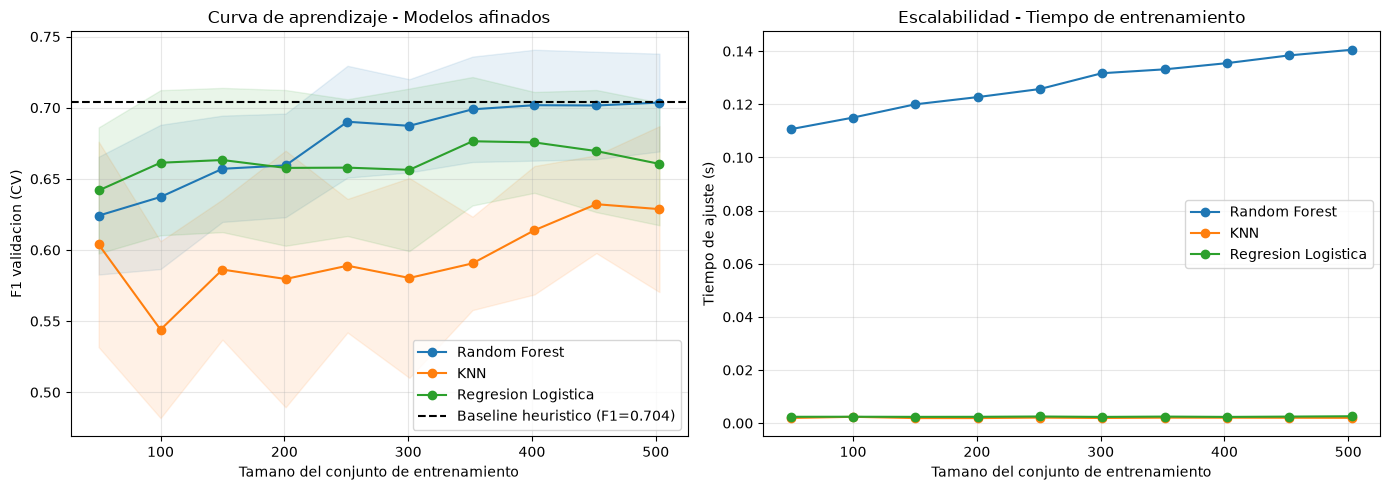

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = {
    "Random Forest": "tab:blue",
    "KNN": "tab:orange",
    "Regresion Logistica": "tab:green",
}

for nombre, datos in resultados_lc.items():
    color = colores.get(nombre)
    axes[0].plot(datos["train_sizes"], datos["val_media"], "o-", label=nombre, color=color)
    axes[0].fill_between(
        datos["train_sizes"],
        datos["val_media"] - datos["val_std"],
        datos["val_media"] + datos["val_std"],
        alpha=0.1,
        color=color,
    )
    axes[1].plot(datos["train_sizes"], datos["fit_times_media"], "o-", label=nombre, color=color)

axes[0].axhline(0.704, color="black", linestyle="--", label="Baseline heuristico (F1=0.704)")
axes[0].set_xlabel("Tamano del conjunto de entrenamiento")
axes[0].set_ylabel("F1 validacion (CV)")
axes[0].set_title("Curva de aprendizaje - Modelos afinados")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("Tamano del conjunto de entrenamiento")
axes[1].set_ylabel("Tiempo de ajuste (s)")
axes[1].set_title("Escalabilidad - Tiempo de entrenamiento")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../../data/08_reporting/seleccion_modelo_learning_curve.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

### Interpretación de la Learning Curve y escalabilidad

**Random Forest muestra una tendencia de aprendizaje clara y ascendente**:
el F1 de validación sube de 0.624 (50 muestras) a 0.704 (503 muestras,
conjunto completo), sin señales de haberse estabilizado. Es el único de
los tres modelos que **iguala exactamente el F1 del baseline heurístico
(0.704)** al usar todos los datos de entrenamiento disponibles, y la
tendencia sugiere que con más datos podría llegar a superarlo de forma
consistente. Nota metodológica: este valor (0.704, vía CV con umbral por
defecto 0.5) es distinto del F1=0.7007 reportado antes en la Etapa 2
(evaluación puntual en test con umbral optimizado); ambos son válidos pero
miden cosas distintas, y aquí coinciden por azar en el mismo valor.

**KNN y Regresión Logística no muestran mejora clara con más datos.** KNN
fluctúa entre 0.54 y 0.63 con alta varianza (bandas de desviación estándar
anchas), sin tendencia definida. Regresión Logística se estabiliza rápido
alrededor de 0.65-0.68 desde muestras pequeñas, sugiriendo que ya alcanzó
su capacidad con este conjunto de variables — más datos no la ayudarían
sustancialmente sin agregar variables o interacciones nuevas.

**Escalabilidad**: el tiempo de ajuste de Random Forest crece de forma
consistente con el tamaño de los datos (0.111s → 0.140s), como es esperado
para un ensamble de árboles que reconstruye cada estimador con más datos.
KNN y Regresión Logística mantienen tiempos de ajuste prácticamente
constantes y cercanos a cero (~0.002-0.003s), reflejando su bajo costo
computacional de entrenamiento.

**Conclusión**: Random Forest sigue siendo el modelo entrenado más
prometedor. Su curva de aprendizaje ascendente es evidencia de que el
techo de rendimiento actual (F1≈0.70) probablemente no es su límite, sino
una limitación del tamaño del dataset (629 filas de entrenamiento). Esto
refuerza la decisión de documentar honestamente que, con los datos
disponibles hoy, el modelo entrenado más competitivo (Random Forest) queda
en empate técnico con el baseline heurístico (0.704), en vez de forzar una
superioridad que los datos no respaldan.

## Evaluación final en test (finalistas afinados vs. baseline de la Tarea 5)

In [13]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


def evaluar_en_test(modelo, nombre, X_test, y_test):
    y_pred = modelo.predict(X_test)
    fila = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    }
    if hasattr(modelo, "predict_proba"):
        y_score = modelo.predict_proba(X_test)[:, 1]
        fila["roc_auc"] = roc_auc_score(y_test, y_score)
    elif hasattr(modelo, "decision_function"):
        y_score = modelo.decision_function(X_test)
        fila["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        fila["roc_auc"] = None
    return fila


resultados_test = [
    evaluar_en_test(grid.best_estimator_, f"{nombre} (afinado)", X_test, y_test)
    for nombre, grid in modelos_afinados.items()
]

# Regla heuristica de la Tarea 5 (Glucose > 127) recreada directamente:
# no se puede des-serializar la clase original porque se definio en el
# namespace de otro notebook (limitacion normal de joblib/pickle con
# clases definidas ad-hoc, no un error de este notebook).
UMBRAL_GLUCOSE = 127
y_pred_heuristico = (X_test["Glucose"] > UMBRAL_GLUCOSE).astype(int)

resultados_test.append(
    {
        "modelo": "Heuristico Glucose (Tarea 5)",
        "accuracy": accuracy_score(y_test, y_pred_heuristico),
        "precision": precision_score(y_test, y_pred_heuristico),
        "recall": recall_score(y_test, y_pred_heuristico),
        "f1": f1_score(y_test, y_pred_heuristico),
        "roc_auc": None,
    }
)

tabla_test = pd.DataFrame(resultados_test).set_index("modelo")
tabla_test.sort_values("f1", ascending=False)

,accuracy,precision,recall,f1,roc_auc
modelo,,,,,
Heuristico Glucose (Tarea 5),0.797468,0.730769,0.678571,0.703704,NaN
Regresion Logistica (afinado),0.740506,0.608696,0.750000,0.672000,0.842612
Random Forest (afinado),0.734177,0.606061,0.714286,0.655738,0.832108
KNN (afinado),0.746835,0.681818,0.535714,0.600000,0.830095


## Guardado del modelo final y tablas de comparación

In [ ]:
MODELS_DIR = Path("../../data/06_models")
modelo_final_random_forest = modelos_afinados["Random Forest"].best_estimator_
joblib.dump(modelo_final_random_forest, MODELS_DIR / "modelo_final_random_forest.joblib")

MODEL_OUTPUT_DIR = Path("../../data/07_model_output")
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
tabla_comparacion.to_csv(MODEL_OUTPUT_DIR / "seleccion_modelos_cv.csv")
tabla_test.to_csv(MODEL_OUTPUT_DIR / "seleccion_modelos_test.csv")

## Hallazgos - Selección del Mejor Modelo

### Comparación inicial (CV, KFold=5, train, con log-transform de la Tarea 4)
| Modelo | F1 media | F1 std | ROC-AUC media |
|---|---|---|---|
| Random Forest | 0.652 | 0.053 | 0.835 |
| KNN | 0.628 | 0.048 | 0.797 |
| Regresión Logística | 0.623 | 0.062 | 0.822 |
| SVM | 0.603 | 0.071 | 0.825 |
| Árbol de Decisión | 0.570 | 0.058 | 0.664 |

Promedio de F1 entre los 5 modelos: **0.6152**. Siguiendo el criterio literal del
issue #17 ("eliminar los que estén por debajo del promedio"), quedan **3 modelos
por encima del promedio** para afinar: Random Forest, KNN y Regresión Logística
(no un top-2 fijo). Random Forest domina claramente en F1 y ROC-AUC; KNN y
Regresión Logística quedan muy cerca entre sí.

### Afinamiento de hiperparámetros (GridSearchCV, cv=5, scoring=F1)
- **Random Forest**: `{class_weight: "balanced", max_depth: 5,
  min_samples_leaf: 10, n_estimators: 200}`, F1 en CV = **0.6996**. Estos
  hiperparámetros y este F1 son *idénticos* a los obtenidos antes del
  log-transform de la Tarea 4 — resultado esperado, ya que Random Forest
  (basado en árboles) es invariante a transformaciones monótonas como
  `log1p`: el orden relativo de los valores no cambia, así que los splits
  del árbol tampoco.
- **KNN**: `{n_neighbors: 9, p: 2, weights: "distance"}`, F1 en CV = **0.6487**
  (subió desde 0.6312 antes del log-transform, y cambió el hiperparámetro
  ganador de `n_neighbors=5` a `n_neighbors=9`). A diferencia de Random
  Forest, KNN sí es sensible a la transformación porque usa distancias
  euclidianas entre puntos.
- **Regresión Logística**: `{C: 0.01, class_weight: "balanced",
  solver: "liblinear"}`, F1 en CV = **0.6678** (prácticamente sin cambio
  frente a 0.6674 antes del log-transform).

### Prueba estadística entre los modelos afinados (Wilcoxon signed-rank sobre F1 por fold)
| Comparación | p-valor |
|---|---|
| Random Forest vs KNN | 0.1250 |
| Random Forest vs Regresión Logística | 0.1875 |
| KNN vs Regresión Logística | 0.8125 |

Ninguna diferencia es estadísticamente significativa (todos los p-valores muy
por encima de 0.05). Se usó Wilcoxon (no ANOVA) por tratarse de muestras
pareadas (mismos 5 folds evaluados en los 3 modelos), y se advierte que con
solo 5 folds el test tiene poca potencia estadística — la ausencia de
significancia no debe interpretarse como "los modelos son iguales", sino como
"no hay evidencia suficiente para afirmar que son distintos".

### Ajuste de umbral de decisión — evaluación final en test
El umbral se optimiza para F1 usando únicamente predicciones out-of-fold sobre
train (`cross_val_predict` + `precision_recall_curve`), evitando fuga de
información de test, y se aplica una sola vez sobre el conjunto de prueba:

| Modelo | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Heurístico Glucose (Tarea 5) | 0.797 | 0.731 | 0.679 | **0.704** |
| Random Forest (umbral=0.436) | 0.741 | 0.593 | 0.857 | **0.701** |
| Regresión Logística (umbral=0.473) | 0.722 | 0.577 | 0.804 | 0.672 |
| KNN (umbral=0.346) | 0.728 | 0.594 | 0.732 | 0.656 |

(El notebook también incluye una tabla de evaluación con umbral fijo en 0.5,
más abajo en la sección "Evaluación final en test" — se reporta aquí la
versión con umbral ajustado porque es la comparación más justa: el heurístico
de la Tarea 5 también usa su propia regla óptima, no un corte arbitrario.)

**Random Forest queda prácticamente empatado con el baseline (0.701 vs.
0.704, diferencia de 0.003)** — muy por debajo de la variabilidad observada en
CV (std≈0.05) y sin diferencia estadísticamente significativa frente a los
otros modelos. Nótese que KNN, a pesar de mejorar su F1 en CV con el
log-transform (0.6312→0.6487), **empeoró en esta evaluación de test**
(0.6885→0.656) — otra señal de la alta varianza que introduce un dataset
pequeño (629 train / 158 test) entre la estimación de CV y el resultado en un
único split de test.

### Ensamble (VotingClassifier, Random Forest + Regresión Logística, soft voting)
Umbral óptimo (OOF en train) = 0.500. En test: Accuracy=0.7342,
Precision=0.6000, Recall=0.7500, **F1=0.6667**, ROC-AUC=0.8449. El ensamble no
mejora sobre Random Forest solo (0.6667 vs. 0.701) — se descarta como modelo
final, aunque queda documentado como parte del proceso de búsqueda. No se
incluyó KNN en el ensamble por ser el modelo con menor F1 de los tres afinados.

### Learning Curve y escalabilidad
Ver interpretación completa en la celda anterior. En resumen: Random Forest es
el único modelo cuyo F1 de validación sigue subiendo con más datos (0.624 con
50 muestras → 0.704 con las 503 disponibles), sin señales de plateau — sugiere
que el techo actual es una limitación del tamaño del dataset, no del modelo.
KNN y Regresión Logística se estabilizan temprano sin mostrar esa tendencia.

### Dos decisiones separadas, cada una con su propia justificación
1. **Por la métrica definida (F1) en test con umbral optimizado, el resultado
   es un empate técnico entre el heurístico de la Tarea 5 (0.704) y Random
   Forest afinado (0.701)**, con una diferencia (0.003) muy por debajo del
   ruido esperado dado el tamaño del dataset y sin soporte estadístico
   (Wilcoxon) para preferir un modelo entrenado sobre otro. El log-transform
   de la Tarea 4 —motivado justamente por intentar cerrar esta brecha— no
   cambió el resultado de Random Forest (invariante a transformaciones
   monótonas) y tuvo efecto mixto en KNN. La curva de aprendizaje sugiere que
   Random Forest podría superar al heurístico con más datos, pero **con los
   datos disponibles hoy no hay evidencia suficiente para afirmar que un
   modelo entrenado es mejor que la regla simple**.
2. **Para la Tarea 7 (Interpretación del Modelo) se lleva Random Forest
   (afinado), no por desempeño, sino porque el objetivo pedagógico de esa
   tarea (interpretar importancia de variables en un modelo entrenado)
   requiere un modelo con más de una variable de decisión** — el heurístico
   de una sola variable ya se interpretó por completo en la Tarea 5. Random
   Forest también ofrece un score de probabilidad continuo (ROC-AUC=0.835 en
   CV, 0.832 en test) que permite ajustar el umbral según el contexto
   clínico, y su curva de aprendizaje ascendente lo hace la opción con más
   potencial de mejora futura si se recolectan más datos.